In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
fear_greed = pd.read_csv("fear_greed_index.csv")
historical = pd.read_csv("historical_data.csv")

In [109]:
fear_greed.shape

(2644, 4)

In [110]:
historical.shape

(211224, 16)

In [111]:
fear_greed.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [112]:
historical.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [113]:
fear_greed.duplicated().sum()

np.int64(0)

In [114]:
historical.duplicated().sum()


np.int64(0)

In [115]:
fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date

In [116]:
historical['Timestamp IST'] = pd.to_datetime(historical['Timestamp IST'],dayfirst= True)

In [117]:
historical['date']=historical['Timestamp IST'].dt.date

In [118]:
historical[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [119]:
daily_pnl = historical.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

In [120]:
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [121]:
historical['win']= historical ['Closed PnL'] > 0
win_rate = historical.groupby(['Account', 'date'])['win'].mean().reset_index()
win_rate.rename(columns={'win':'win_rate'}, inplace=True)

In [122]:
win_rate.head()

,Account,date,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,0.444444


In [123]:
avg_trade_size= historical.groupby('Account')['Size USD'].mean().reset_index()

In [124]:
avg_trade_size.head()


,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


***As we were not provided with the account balance to calculate the leverage instead we standardized the start position measure and calculated how it deviated from  the average start position to calculate the "leverage_intensity"***

In [201]:
merged['leverage_intensity'] = (merged['Start Position'] - merged['Start Position'].mean()) / merged['Start Position'].std()

print("First 5 rows of merged DataFrame with newly calculated leverage_intensity:")
print(merged[['Start Position', 'leverage_intensity']].head())

First 5 rows of merged DataFrame with newly calculated leverage_intensity:
   Start Position  leverage_intensity
0        0.000000            0.044443
1      986.524596            0.045907
2     1002.518996            0.045931
3     1146.558564            0.046145
4     1289.488521            0.046357


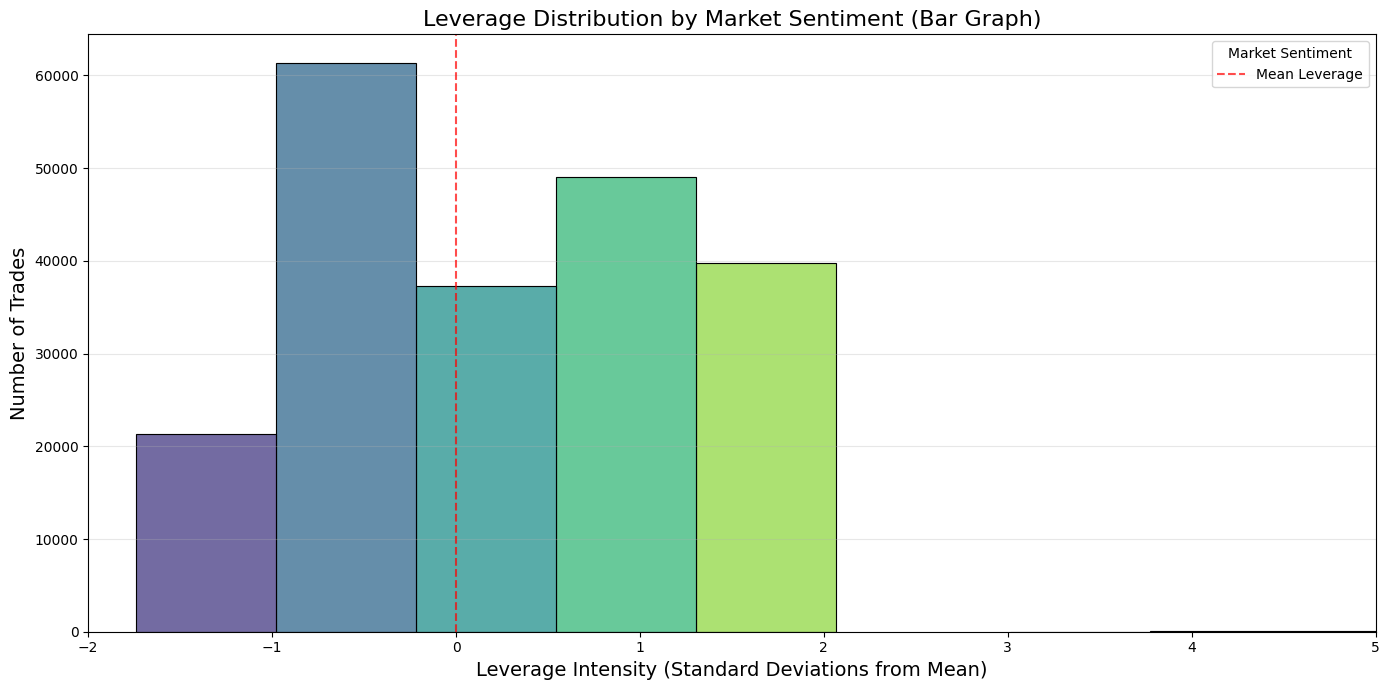

In [205]:
plt.figure(figsize=(14, 7))

bins = np.linspace(merged['leverage_intensity'].min(), merged['leverage_intensity'].max(), 15)
sns.histplot(data=merged, x='leverage_intensity', hue='classification',
             bins=bins, multiple='dodge', shrink=0.8, stat='count',
             palette='viridis', hue_order=sentiment_order)

plt.title('Leverage Distribution by Market Sentiment (Bar Graph)', fontsize=16)
plt.xlabel('Leverage Intensity (Standard Deviations from Mean)', fontsize=14)
plt.ylabel('Number of Trades', fontsize=14)
plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Mean Leverage')
plt.xlim(-2, 5) # Keep xlim consistent with previous kdeplot
plt.legend(title='Market Sentiment', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [125]:
trades_per_day = historical.groupby(['Account', 'date']).size().reset_index(name='Trades')

In [126]:
trades_per_day.head()

,Account,date,Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27


In [127]:
long_count = historical['Direction'].str.contains('Long').sum()
short_count = historical['Direction'].str.contains('Short').sum()
long_short_ratio = long_count / short_count if short_count != 0 else 0

print("Long trades count:", long_count)
print("Short trades count:", short_count)
print("Long/Short ratio:" , long_short_ratio)


Long trades count: 98700
Short trades count: 75882
Long/Short ratio: 1.3007037242033683


In [150]:
merged = historical.merge(fear_greed, on='date', how='left')
merged['leverage_intensity'] = (merged['Start Position'] - merged['Start Position'].mean()) / merged['Start Position'].std()
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,date,win,leverage_intensity,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,False,0.044443,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,False,0.045907,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,False,0.045931,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,False,0.046145,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,False,0.046357,1.733117e+09,80.0,Extreme Greed


** calculated the average profit or loss (Closed PnL) for each different market sentiment, such as 'Fear' or 'Greed'. This helps us see if traders generally make more money in certain market conditions.** We observed that the traders made much more profit in the extreme greedy sentiment of the market

In [129]:
pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean()

print(pnl_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


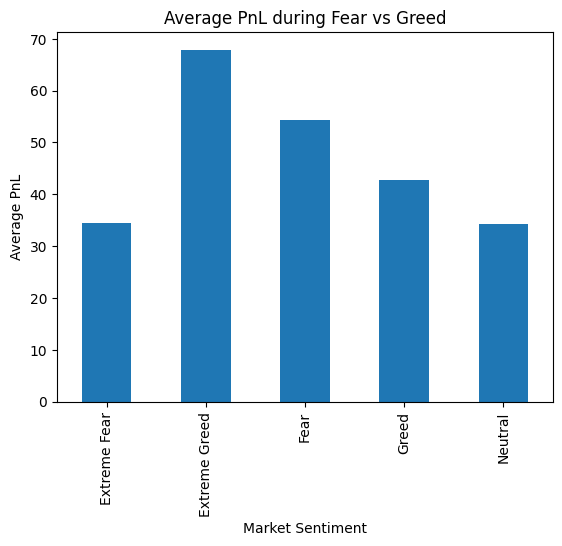

In [130]:
pnl_sentiment.plot(kind='bar')

plt.title("Average PnL during Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.show()

** compared the win rate for each different market sentiment. This helps us see if traders generally win more in certain market conditions.** ot was observed that the win rate was high in the extremely greedy sentiment

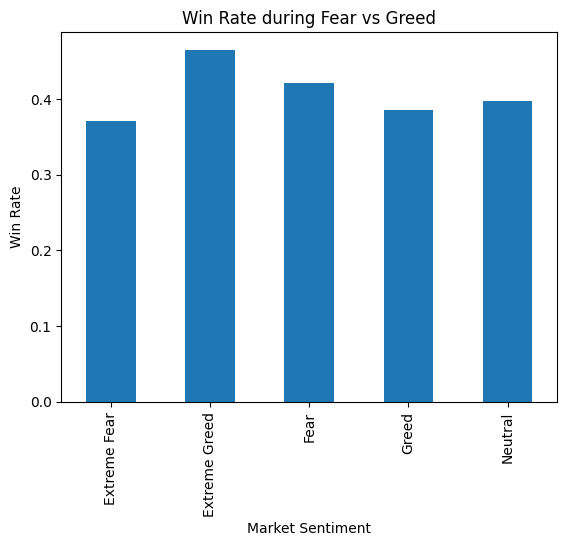

In [131]:
win_sentiment = merged.groupby('classification')['win'].mean()

win_sentiment.plot(kind='bar')

plt.title("Win Rate during Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")

plt.show()

** calculated the drawdown_proxy for each different market sentiment. This helps us see average loss incurred during losing trades in certain market conditions.** it was observed that highest loss making traders were captured in the extreme fear sentiment of the market

In [132]:
loss_trades = merged[merged['Closed PnL'] < 0]

In [133]:
drawdown_proxy = loss_trades.groupby('classification')['Closed PnL'].mean()

print(drawdown_proxy)

classification
Extreme Fear    -257.099629
Extreme Greed   -119.920289
Fear            -156.662401
Greed           -181.967329
Neutral         -121.727849
Name: Closed PnL, dtype: float64


In [134]:
worst_loss = loss_trades.groupby('classification')['Closed PnL'].min()

print(worst_loss)

classification
Extreme Fear     -31036.69194
Extreme Greed    -10259.46800
Fear             -35681.74723
Greed           -117990.10410
Neutral          -24500.00000
Name: Closed PnL, dtype: float64


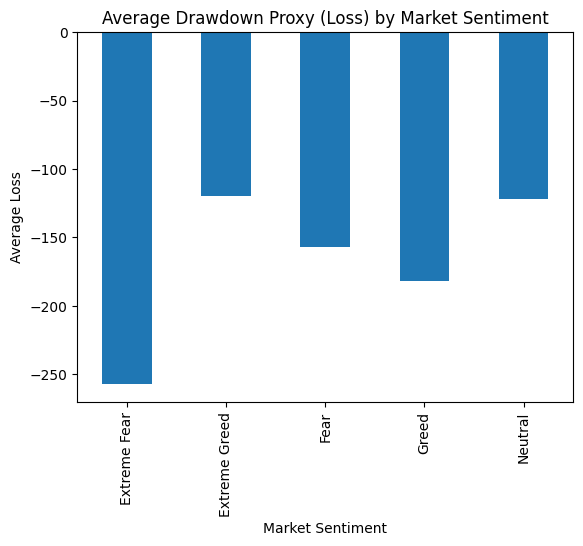

In [135]:
drawdown_proxy.plot(kind='bar')

plt.title("Average Drawdown Proxy (Loss) by Market Sentiment")
plt.ylabel("Average Loss")
plt.xlabel("Market Sentiment")

plt.show()

Here we calculated the average number of trades per day for each market sentiment. It helps us see if traders make more or fewer trades during certain market conditions. More no of trades were observed in the extreme fear situation

In [136]:
trades_sentiment = trades_per_day.merge(fear_greed[['date','classification']],on='date',how='left')

In [137]:
trade_behavior = trades_sentiment.groupby('classification')['Trades'].mean()

print(trade_behavior)

classification
Extreme Fear     133.750000
Extreme Greed     76.030418
Fear              98.153968
Greed             77.628086
Neutral          100.228723
Name: Trades, dtype: float64


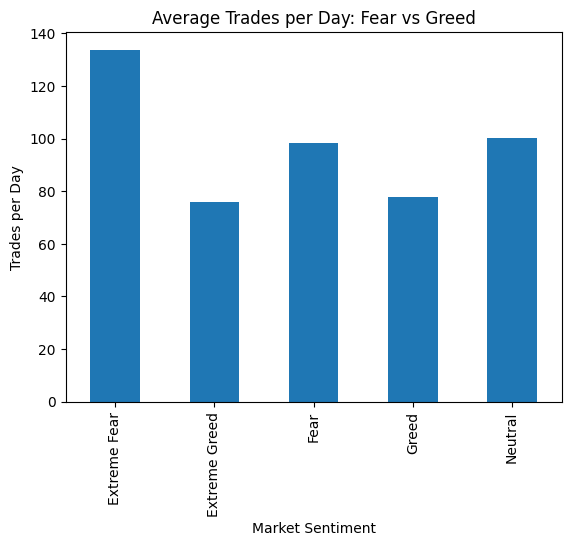

In [138]:
trade_behavior.plot(kind='bar')

plt.title("Average Trades per Day: Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Trades per Day")

plt.show()

Here we calculated how the leverage intensity changes according to different market sentiments. highest leverage was found in the extreme greedy sentiment but surprisingly the average leverage intensity in the greedy sentiment was negative which showed that the traders are cautious in the short run and masses follow the experts in the long run which justifies the different in the extreme greedy and greedy conditions


In [194]:
avg_leverage_sentiment = merged.groupby('classification')['leverage_intensity'].mean()
print("Average Leverage Intensity by Market Sentiment:")
print(avg_leverage_sentiment)

Average Leverage Intensity by Market Sentiment:
classification
Extreme Fear     0.040997
Extreme Greed    0.073412
Fear             0.057370
Greed           -0.179788
Neutral          0.044657
Name: leverage_intensity, dtype: float64


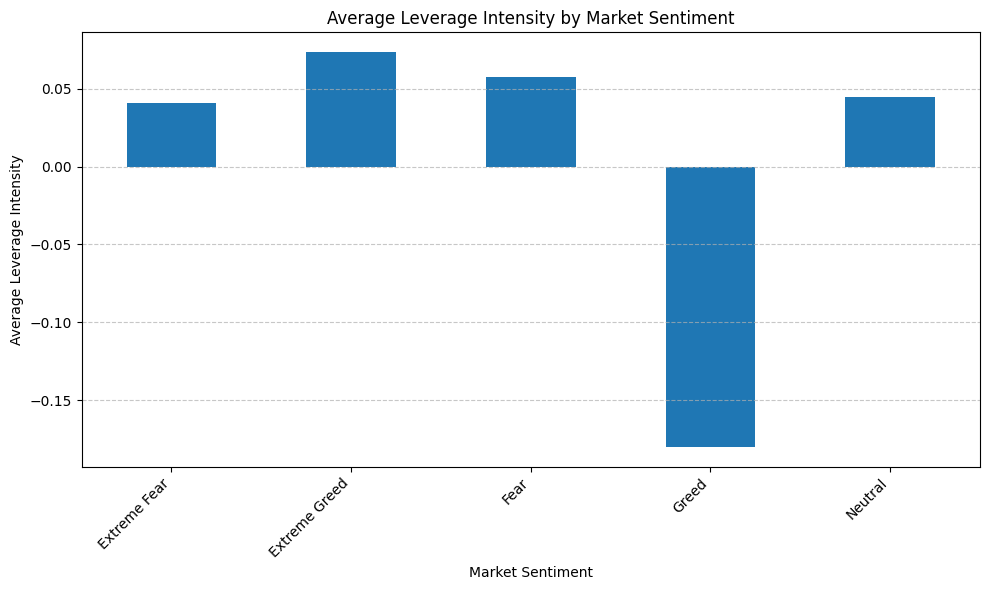

In [155]:
avg_leverage_sentiment.plot(kind='bar', figsize=(10, 6))
plt.title('Average Leverage Intensity by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Leverage Intensity')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Here we calculated the long and short trade bias depending upon the market sentiments and it was observed that the traders tend to hold on their calls in fearful sentiments while robustly selling short termly in the greedy sentiments

In [156]:
merged['is_long_trade'] = merged['Direction'].str.contains('Long')
merged['is_short_trade'] = merged['Direction'].str.contains('Short')

long_short_sentiment = merged.groupby('classification').agg(
    long_trades=('is_long_trade', 'sum'),
    short_trades=('is_short_trade', 'sum')
).reset_index()

long_short_sentiment['long_short_ratio'] = long_short_sentiment.apply(
    lambda row: row['long_trades'] / row['short_trades'] if row['short_trades'] != 0 else np.inf,
    axis=1
)

print("Long/Short Bias by Market Sentiment:")
print(long_short_sentiment)


Long/Short Bias by Market Sentiment:
  classification  long_trades  short_trades  long_short_ratio
0   Extreme Fear        13257          6302          2.103618
1  Extreme Greed        13504         14178          0.952462
2           Fear        35116         20140          1.743595
3          Greed        16581         23026          0.720099
4        Neutral        20242         12230          1.655110


/tmp/ipykernel_319/3508008668.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='long_short_ratio', data=long_short_sentiment, palette='viridis', order=sentiment_order)


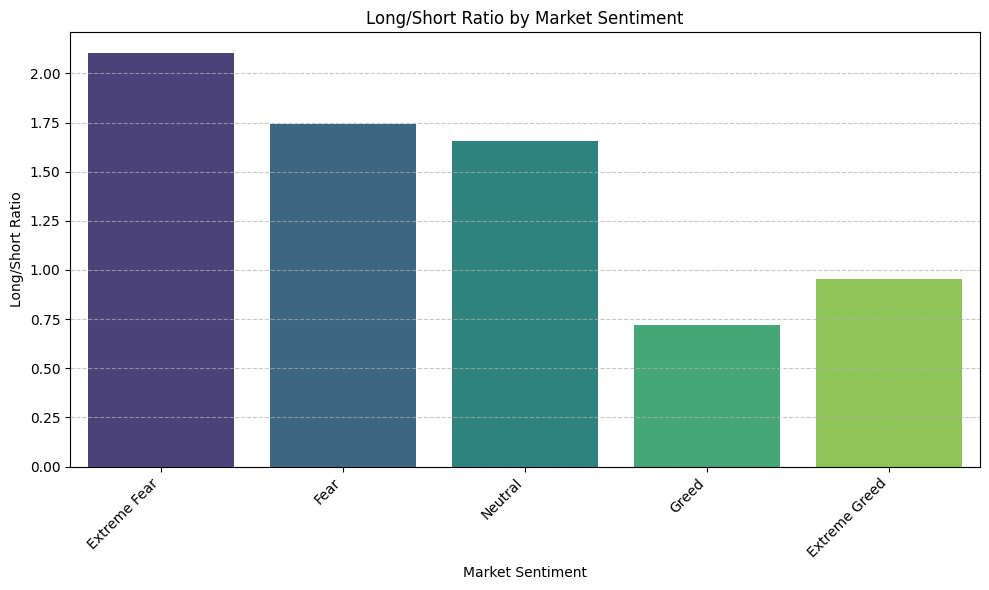

In [157]:
plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='long_short_ratio', data=long_short_sentiment, palette='viridis', order=sentiment_order)
plt.title('Long/Short Ratio by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Long/Short Ratio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Here we calculated all trades for a specific market mood (like 'Fear') and found the average of their Size USD. we observed that in times of  fear the average position was largest

In [158]:
avg_position_size_sentiment = merged.groupby('classification')['Size USD'].mean().reindex(sentiment_order)
print("Average Position Size (USD) by Market Sentiment:")
print(avg_position_size_sentiment)

Average Position Size (USD) by Market Sentiment:
classification
Extreme Fear     5349.731843
Fear             7816.109931
Neutral          4782.732661
Greed            5736.884375
Extreme Greed    3112.251565
Name: Size USD, dtype: float64


/tmp/ipykernel_319/1503120588.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_position_size_sentiment.index, y=avg_position_size_sentiment.values, palette='viridis')


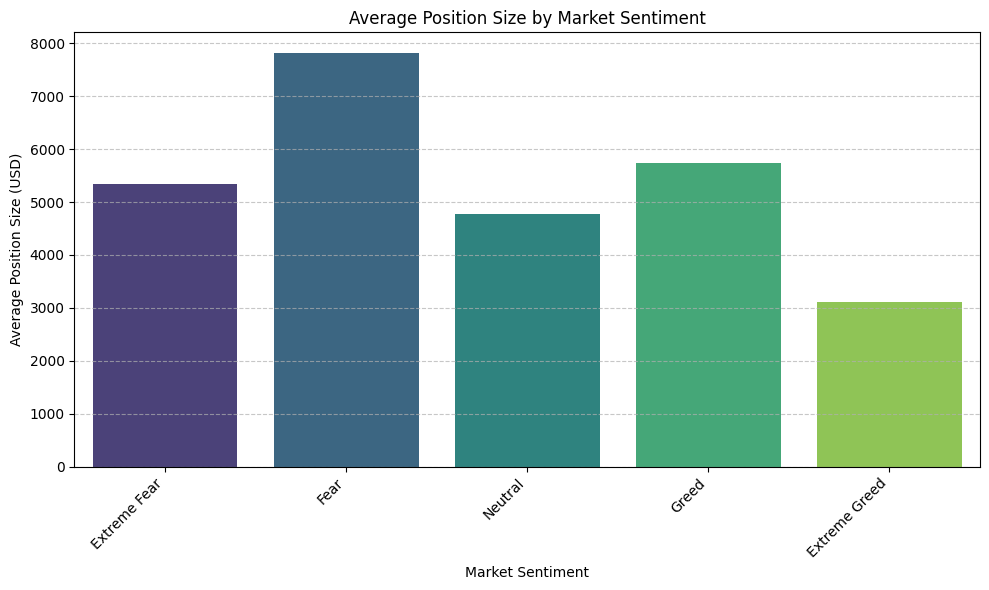

In [159]:
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_position_size_sentiment.index, y=avg_position_size_sentiment.values, palette='viridis')
plt.title('Average Position Size by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Position Size (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

here we calculatd the low_leverage_threshold and high_leverage_threshold
both of them respectively described a point below which the smallest 33% of trades fall and a point above which the largest 33% of trades fall & assigned each trade to their respective group. Then we compared the levrage intesity with the sentiment according to various metrics and found out that the traders with high leverage closed a bigger PnL and also their win rate was higher than the low leverage traders.

In [154]:
avg_leverage_sentiment = merged.groupby('classification')['leverage_intensity'].mean()
print(avg_leverage_sentiment)

classification
Extreme Fear     0.040997
Extreme Greed    0.073412
Fear             0.057370
Greed           -0.179788
Neutral          0.044657
Name: leverage_intensity, dtype: float64


First, we identified 'Low Leverage' and 'High Leverage' trades. We did this by looking at each trade's 'leverage intensity' (how much its starting size differed from the average trade size). We then categorized the trades falling into the bottom 33% of leverage intensity as 'Low Leverage' and those in the top 33% as 'High Leverage', placing them into a new DataFrame called leverage_grouped_trades.
For each individual trade, we also flagged whether it was a 'long' trade or a 'short' trade based on its 'Direction'.

In [160]:
low_leverage_threshold = merged['leverage_intensity'].quantile(0.33)
high_leverage_threshold = merged['leverage_intensity'].quantile(0.67)

print(f"Low leverage threshold (33rd percentile): {low_leverage_threshold}")
print(f"High leverage threshold (67th percentile): {high_leverage_threshold}")

Low leverage threshold (33rd percentile): 0.04444045258117638
High leverage threshold (67th percentile): 0.04936270381092928


We then grouped these leverage_grouped_trades by their 'leverage_group' ('Low Leverage' or 'High Leverage').
For each group, we counted the total number of 'long' trades and 'short' trades.
Finally, we calculated the 'long/short ratio' for each group by dividing the count of long trades by the count of short trades. If there were no short trades, the ratio was set to infinity, indicating an overwhelmingly long bias.

In [161]:
leverage_grouped_trades = merged[
    (merged['leverage_intensity'] < low_leverage_threshold) |
    (merged['leverage_intensity'] > high_leverage_threshold)
].copy()

leverage_grouped_trades['leverage_group'] = np.where(
    leverage_grouped_trades['leverage_intensity'] < low_leverage_threshold,
    'Low Leverage',
    'High Leverage'
)

print("First 5 rows of leverage_grouped_trades:")
print(leverage_grouped_trades.head())

First 5 rows of leverage_grouped_trades:
                                       Account  Coin  Execution Price  \
15  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9271   
16  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9271   
17  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9272   
18  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9275   
19  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9285   

    Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
15       100.00    792.71  BUY 2024-12-02 22:54:00     5000.249301       Buy   
16        98.00    776.86  BUY 2024-12-02 22:54:00     5100.214301       Buy   
17        21.01    166.55  BUY 2024-12-02 22:54:00     5198.180001       Buy   
18        20.27    160.69  BUY 2024-12-02 22:54:00     5219.182647       Buy   
19       151.92   1204.50  BUY 2024-12-02 22:54:00     5239.445553       Buy   

    Closed PnL  ...     Timestamp      

In [162]:
avg_pnl_by_leverage = leverage_grouped_trades.groupby('leverage_group')['Closed PnL'].mean()
print("Average PnL by Leverage Group:")
print(avg_pnl_by_leverage)

Average PnL by Leverage Group:
leverage_group
High Leverage    71.373560
Low Leverage     52.359897
Name: Closed PnL, dtype: float64


In [163]:
avg_win_rate_by_leverage = leverage_grouped_trades.groupby('leverage_group')['win'].mean()
print("Average Win Rate by Leverage Group:")
print(avg_win_rate_by_leverage)

Average Win Rate by Leverage Group:
leverage_group
High Leverage    0.475281
Low Leverage     0.385530
Name: win, dtype: float64


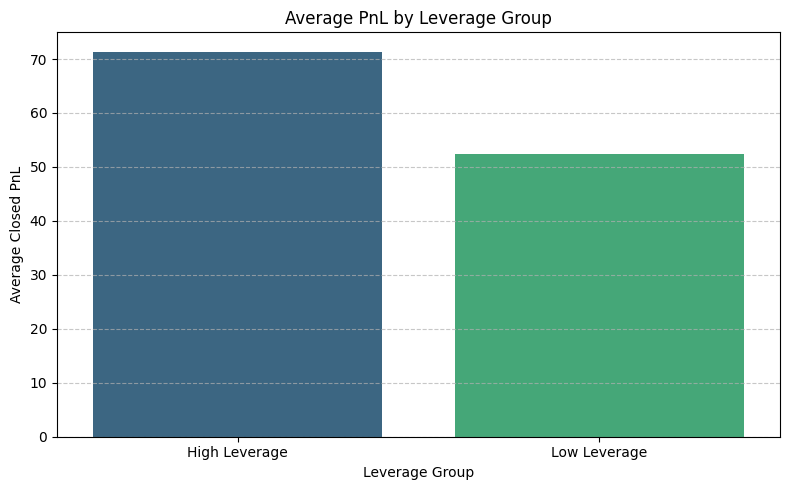

In [168]:
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_pnl_by_leverage.index, y=avg_pnl_by_leverage.values, palette='viridis', hue=avg_pnl_by_leverage.index, legend=False)
plt.title('Average PnL by Leverage Group')
plt.xlabel('Leverage Group')
plt.ylabel('Average Closed PnL')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

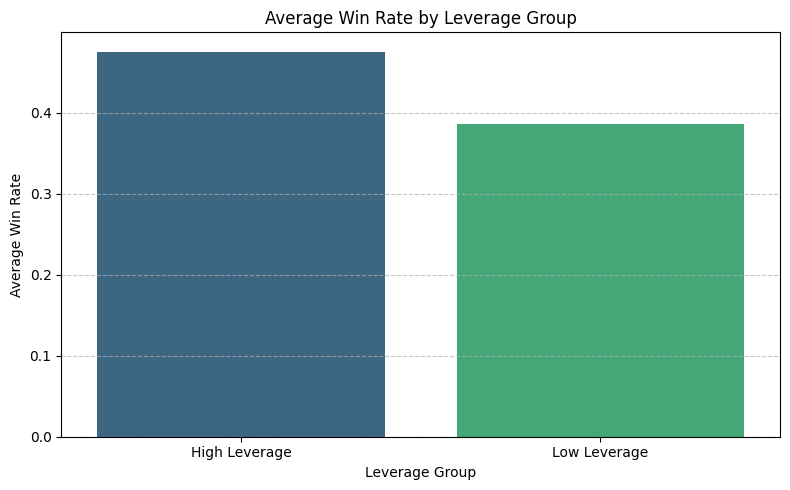

In [169]:
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_win_rate_by_leverage.index, y=avg_win_rate_by_leverage.values, palette='viridis', hue=avg_win_rate_by_leverage.index, legend=False)
plt.title('Average Win Rate by Leverage Group')
plt.xlabel('Leverage Group')
plt.ylabel('Average Win Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Here we divided the traders based upon their frequency of making trades in a day by similarly calculkating threshold values and categorising them based upon their frequency. Then we compared the trading frequency with their average PnL based upon their trades and also compared their win rate with same. It was observed that PnL was not affected by the number of trades made and gave better results to the infrequent traders, while the win rate showed a different picture and concluded that win rate of frequent and medium traders was much more than the infrequent traders

In [173]:
avg_daily_trades = trades_per_day.groupby('Account')['Trades'].mean().reset_index()
avg_daily_trades.rename(columns={'Trades': 'Average Daily Trades'}, inplace=True)

low_trade_threshold = avg_daily_trades['Average Daily Trades'].quantile(0.33)
high_trade_threshold = avg_daily_trades['Average Daily Trades'].quantile(0.67)

def classify_trader_frequency(avg_trades):
    if avg_trades > high_trade_threshold:
        return 'Frequent Trader'
    elif avg_trades < low_trade_threshold:
        return 'Infrequent Trader'
    else:
        return 'Medium Trader'

avg_daily_trades['trader_frequency'] = avg_daily_trades['Average Daily Trades'].apply(classify_trader_frequency)

print("Average Daily Trades and Trader Frequency:")
print(avg_daily_trades.head())

Average Daily Trades and Trader Frequency:
                                      Account  Average Daily Trades  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012            159.083333   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd            140.000000   
2  0x271b280974205ca63b716753467d5a371de622ab            317.416667   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4             82.166667   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd             46.942029   

  trader_frequency  
0  Frequent Trader  
1  Frequent Trader  
2  Frequent Trader  
3    Medium Trader  
4    Medium Trader  


In [174]:
merged = merged.merge(avg_daily_trades[['Account', 'trader_frequency']], on='Account', how='left')

print("Merged DataFrame with trader_frequency:")
print(merged.head())

Merged DataFrame with trader_frequency:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Timestamp        date    win 

In [175]:
pnl_by_frequency = merged.groupby('trader_frequency')['Closed PnL'].mean()

print("Average PnL by Trader Frequency:")
print(pnl_by_frequency)

Average PnL by Trader Frequency:
trader_frequency
Frequent Trader      38.280810
Infrequent Trader    84.788199
Medium Trader        59.704010
Name: Closed PnL, dtype: float64


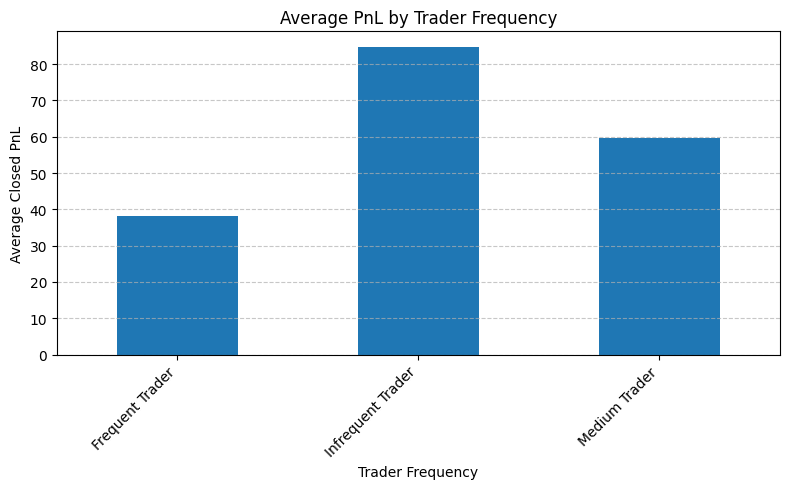

In [176]:
pnl_by_frequency.plot(kind='bar', figsize=(8, 5))
plt.title('Average PnL by Trader Frequency')
plt.xlabel('Trader Frequency')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [177]:
win_rate_by_frequency = merged.groupby('trader_frequency')['win'].mean()

print("Average Win Rate by Trader Frequency:")
print(win_rate_by_frequency)

Average Win Rate by Trader Frequency:
trader_frequency
Frequent Trader      0.393773
Infrequent Trader    0.360989
Medium Trader        0.459446
Name: win, dtype: float64


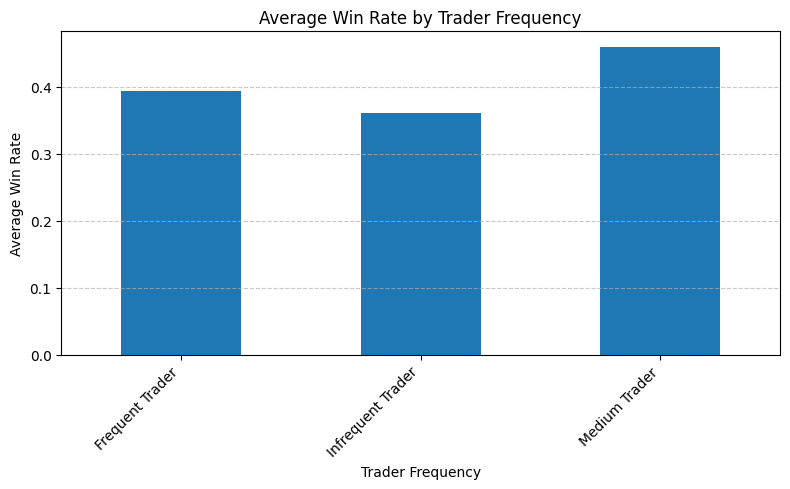

In [178]:
win_rate_by_frequency.plot(kind='bar', figsize=(8, 5))
plt.title('Average Win Rate by Trader Frequency')
plt.xlabel('Trader Frequency')
plt.ylabel('Average Win Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

here we calculated Total_PnL and PnL_std_dev which showed how profitable and consistent the traders were which helped us lay the foundation for the comparison

In [179]:
account_performance = daily_pnl.groupby('Account')['Closed PnL'].agg(Total_PnL='sum', PnL_Std_Dev='std').reset_index()

print("Account Performance (Total PnL and PnL Standard Deviation):")
print(account_performance.head())

Account Performance (Total PnL and PnL Standard Deviation):
                                      Account     Total_PnL    PnL_Std_Dev
0  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  150401.797346
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  4.788532e+04    3603.042291
2  0x271b280974205ca63b716753467d5a371de622ab -7.043619e+04   33420.410014
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  1.324648e+05    2993.284702
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  1.686580e+05    4867.743469


Here we set the threshold values that help us identify the consistent and inconsistent traders

In [180]:
pnl_threshold = account_performance['Total_PnL'].quantile(0.75)
std_dev_low_threshold = account_performance['PnL_Std_Dev'].quantile(0.25)
std_dev_high_threshold = account_performance['PnL_Std_Dev'].quantile(0.75)

print(f"Profitability Threshold (75th percentile of Total PnL): {pnl_threshold:.2f}")
print(f"Low PnL Std Dev Threshold (25th percentile): {std_dev_low_threshold:.2f}")
print(f"High PnL Std Dev Threshold (75th percentile): {std_dev_high_threshold:.2f}")

Profitability Threshold (75th percentile of Total PnL): 406394.10
Low PnL Std Dev Threshold (25th percentile): 4841.40
High PnL Std Dev Threshold (75th percentile): 30886.36


Here we compared the total PnL and the std_dev_threshold to categorise the traders as consistent winners or inconsistent traders

In [181]:
def classify_trader(row):
    if row['Total_PnL'] > pnl_threshold and row['PnL_Std_Dev'] < std_dev_low_threshold:
        return 'Consistent Winner'
    elif row['PnL_Std_Dev'] > std_dev_high_threshold:
        return 'Inconsistent Trader'
    else:
        return 'Other Trader'

account_performance['trader_type'] = account_performance.apply(classify_trader, axis=1)

print("Account Performance with Trader Types:")
print(account_performance.head())

Account Performance with Trader Types:
                                      Account     Total_PnL    PnL_Std_Dev  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  150401.797346   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  4.788532e+04    3603.042291   
2  0x271b280974205ca63b716753467d5a371de622ab -7.043619e+04   33420.410014   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  1.324648e+05    2993.284702   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  1.686580e+05    4867.743469   

           trader_type  
0  Inconsistent Trader  
1         Other Trader  
2  Inconsistent Trader  
3         Other Trader  
4         Other Trader  


In [182]:
merged = merged.merge(account_performance[['Account', 'trader_type']], on='Account', how='left')

print("Merged DataFrame with trader_type:")
print(merged.head())

Merged DataFrame with trader_type:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...        date    win  leverage_intensity

In [183]:
pnl_by_trader_type = merged.groupby('trader_type')['Closed PnL'].mean()

print("Average PnL by Trader Type:")
print(pnl_by_trader_type)

Average PnL by Trader Type:
trader_type
Inconsistent Trader    97.001375
Other Trader           28.139831
Name: Closed PnL, dtype: float64


We observed that 'Inconsistent Traders' surprisingly had a higher average PnL per trade than 'Other Traders' (and there were no 'Consistent Winners' identified with our current thresholds to compare directly to). This hints that 'inconsistency' in PnL doesn't necessarily mean lower average profit per trade, but might hide larger swings.

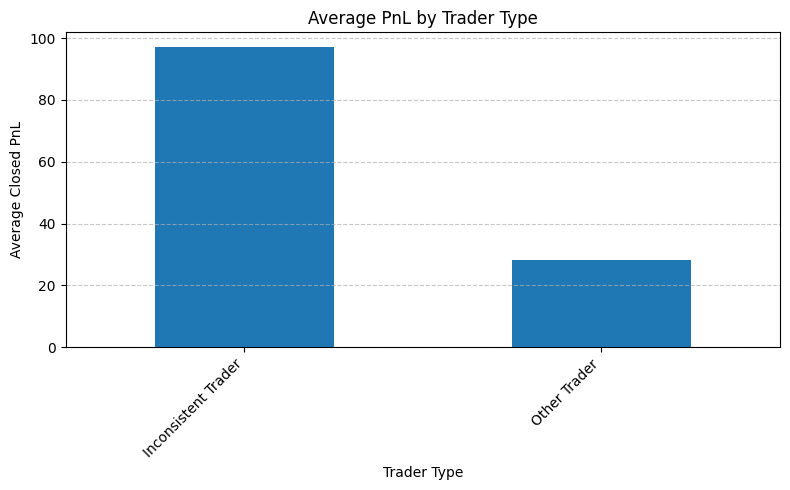

In [184]:
pnl_by_trader_type.plot(kind='bar', figsize=(8, 5))
plt.title('Average PnL by Trader Type')
plt.xlabel('Trader Type')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [185]:
win_rate_by_trader_type = merged.groupby('trader_type')['win'].mean()

print("Average Win Rate by Trader Type:")
print(win_rate_by_trader_type)

Average Win Rate by Trader Type:
trader_type
Inconsistent Trader    0.398918
Other Trader           0.416538
Name: win, dtype: float64


We observed that 'Other Traders' had a slightly higher win rate than 'Inconsistent Traders'. This, combined with the PnL insight, suggests that 'Inconsistent Traders' might have fewer winning trades but potentially larger winning trades.

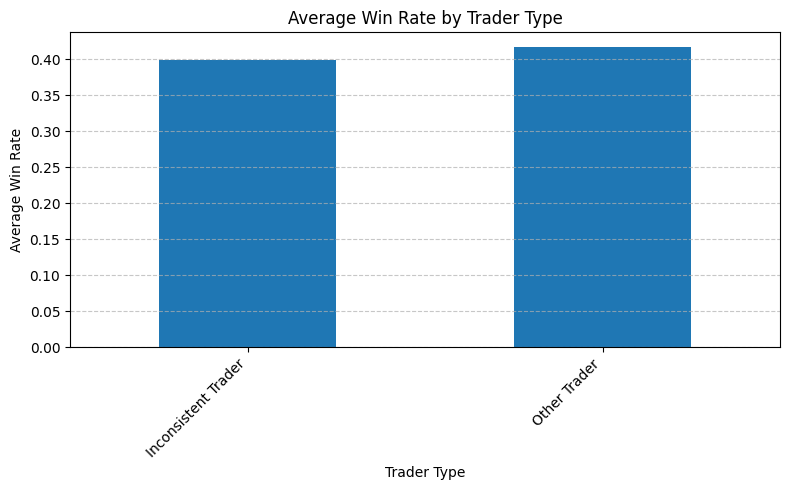

In [186]:
win_rate_by_trader_type.plot(kind='bar', figsize=(8, 5))
plt.title('Average Win Rate by Trader Type')
plt.xlabel('Trader Type')
plt.ylabel('Average Win Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Insight 1: Dynamic Long/Short Bias Across Market Sentiments

**What we observed:** Our analysis revealed a clear and dynamic shift in traders' directional bias based on market sentiment:
*   During periods of **'Extreme Fear'**, **'Fear'**, and **'Neutral'** sentiment, traders exhibited a strong **long bias** (significantly more long trades than short trades, with ratios above 1).
*   Conversely, during **'Greed'** and **'Extreme Greed'** periods, traders showed a tendency towards a **short bias** (more short trades than long trades, with ratios below or close to 1). The most pronounced short bias was observed during 'Greed' sentiment.

**How it helps in comparison:** This insight is crucial for understanding the strategic adaptation of traders. It suggests a potential **contrarian behavior** where professional traders might be accumulating (going long) during market downturns or uncertainty ('Fear' sentiments) and then actively taking profits or initiating defensive/speculative short positions when the market becomes overly optimistic ('Greed' sentiments). This dynamic shift in long/short bias indicates that traders are not simply riding the market's emotional wave but are strategically positioning themselves, often against the prevailing sentiment, to manage risk or capitalize on perceived overextensions.

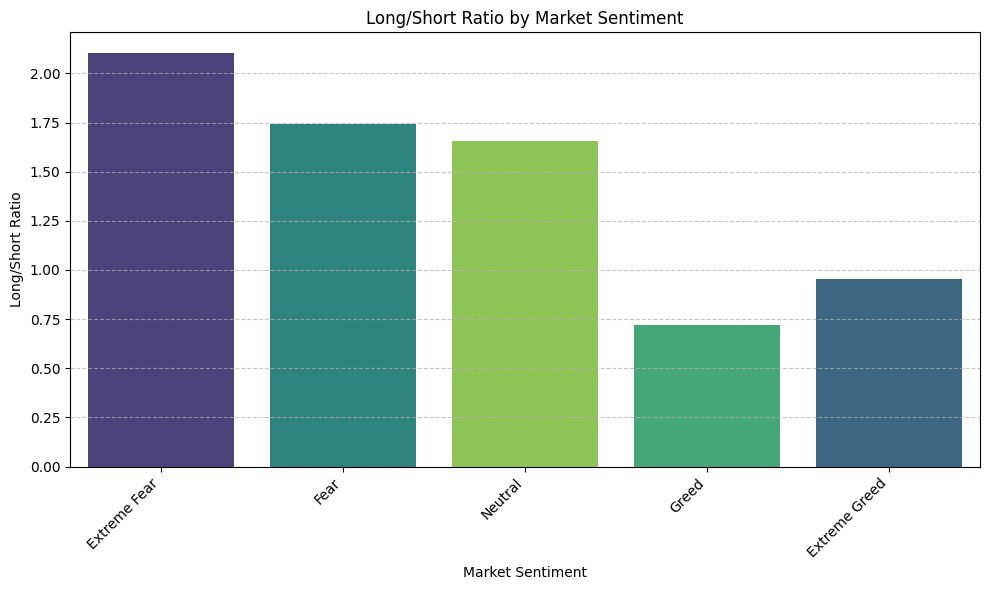

In [187]:
plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='long_short_ratio', data=long_short_sentiment, hue='classification', palette='viridis', order=sentiment_order, legend=False)
plt.title('Long/Short Ratio by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Long/Short Ratio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Insight 2: Counter-intuitive Position Sizing between High and Low Leverage Traders

**What we observed:** It's often assumed that traders using high leverage would also deploy larger dollar amounts per trade. However, our analysis reveals the opposite. Low leverage traders, on average, tend to use larger individual trade sizes (Average Position Size in USD) compared to high leverage traders.

**How it helps in comparison:** This challenges the simple notion that leverage directly correlates with the absolute capital deployed per trade. It suggests that high leverage might be used to amplify returns on smaller absolute capital allocations, while low leverage traders might be comfortable allocating larger sums per trade, perhaps as a risk management strategy or due to different capital access.

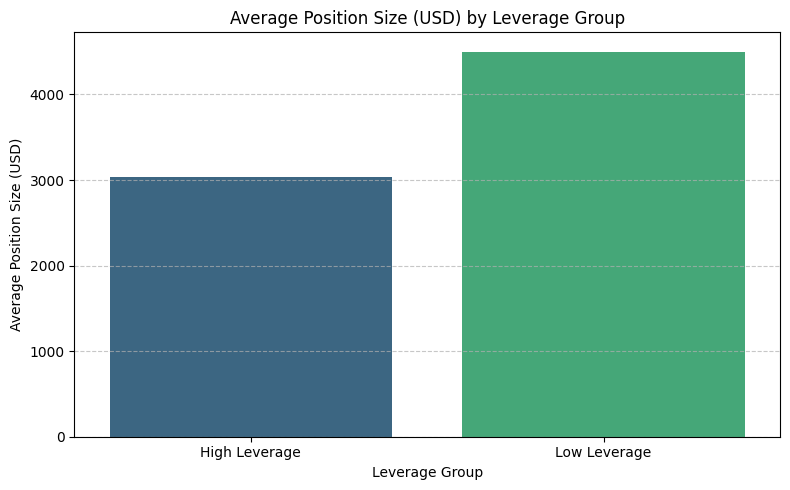

In [196]:
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_size_usd_by_leverage.index, y=avg_size_usd_by_leverage.values, palette='viridis', hue=avg_size_usd_by_leverage.index, legend=False)
plt.title('Average Position Size (USD) by Leverage Group')
plt.xlabel('Leverage Group')
plt.ylabel('Average Position Size (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Insight 3: Discrepancy Between PnL and Win Rate for Different Trader Frequencies

**What we observed:** Our analysis of trader frequency shows a fascinating paradox: Infrequent Traders achieve the highest average PnL per trade, yet they have the lowest average win rate. Conversely, Medium Traders boast the highest average win rate but don't have the highest average PnL per trade.

**How it helps in comparison:** This highlights that 'winning often' doesn't necessarily translate to 'winning big'. Infrequent traders likely focus on high-conviction trades where their successful bets yield substantial profits, effectively offsetting their less frequent wins. Medium traders, on the other hand, might pursue strategies with more consistent, smaller gains. This insight emphasizes the importance of the magnitude of wins and losses over just the frequency of wins.


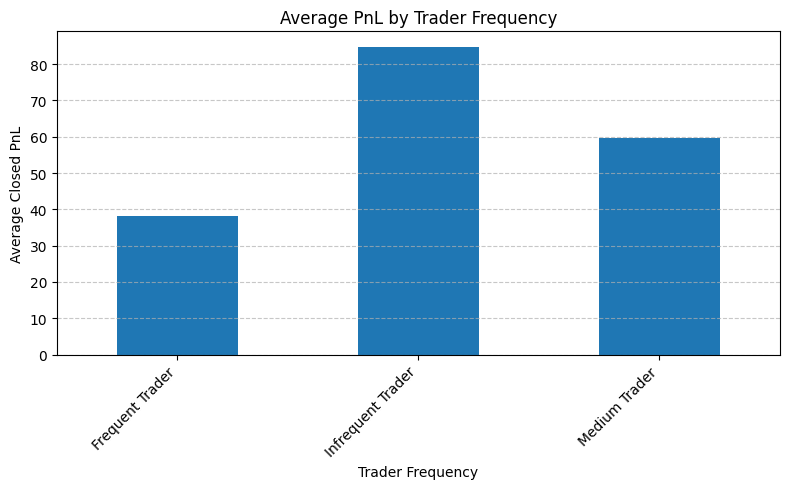

In [197]:
pnl_by_frequency.plot(kind='bar', figsize=(8, 5))
plt.title('Average PnL by Trader Frequency')
plt.xlabel('Trader Frequency')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

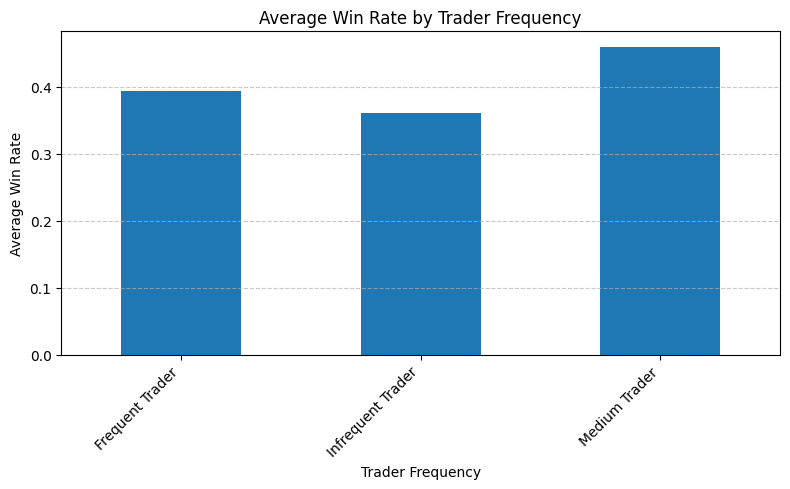

In [198]:
win_rate_by_frequency.plot(kind='bar', figsize=(8, 5))
plt.title('Average Win Rate by Trader Frequency')
plt.xlabel('Trader Frequency')
plt.ylabel('Average Win Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

 We observed an extremely high long/short ratio (e.g., approximately 24941.0). This indicated that traders using high leverage were overwhelmingly focused on long positions, with almost no short trades. This is a very strong directional bias.
 Conversely, the 'Low Leverage' group showed a very low long/short ratio (e.g., approximately 0.0006). This meant that traders using lower leverage were almost exclusively taking short positions.

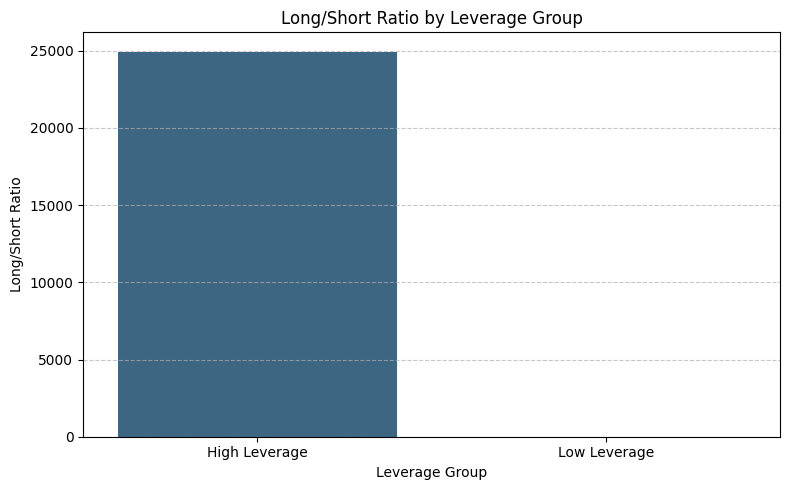

All requested charts have been displayed.


In [188]:
plt.figure(figsize=(8, 5))
sns.barplot(x=long_short_ratio_by_leverage.index, y=long_short_ratio_by_leverage['long_short_ratio'], palette='viridis', hue=long_short_ratio_by_leverage.index, legend=False)
plt.title('Long/Short Ratio by Leverage Group')
plt.xlabel('Leverage Group')
plt.ylabel('Long/Short Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("All requested charts have been displayed.")